# Kelly & Pruitt (2013): Summary Statistics and Replication Walkthrough

This notebook provides a guided tour of the data and methodology used to replicate **Table 1** of:

> Kelly, B. and Pruitt, S. (2013), "Market Expectations in the Cross-Section of Present Values." *The Journal of Finance*, 68: 1721-1756.

The core insight is that a single factor extracted from the cross-section of book-to-market (BM) ratios can forecast aggregate market returns. The extraction uses a **three-pass regression filter** (also known as partial least squares / PLS), which is designed to handle large panels of predictors even when the time series is short.

We walk through:
1. **Data Ingestion & Cleaning** — How we process Fama-French portfolio data
2. **Summary Statistics** — Descriptive statistics for BM ratios and market returns
3. **Data Sparsity** — Availability of cross-sectional predictors over time
4. **The Three-Pass Regression Filter** — Visualizing each intermediate stage
5. **Table 1 Results** — Comparing our replication to the published values

In [16]:
import pandas as pd
import numpy as np
from IPython.display import Image, display, Markdown
from pathlib import Path

# Import our custom modules
import load_data
import regression_tools as rt
from settings import config

OUTPUT_DIR = Path(config("OUTPUT_DIR"))
START_TRAIN_DATE = config("START_TRAIN_DATE")
START_TEST_DATE = config("START_TEST_DATE")
END_TEST_DATE = config("END_TEST_DATE")

# Load all cleaned datasets
data = load_data.clean_kelly_pruitt_data(load_from_cache=True)
print(f"Loaded {len(data)} datasets: {list(data.keys())}")

Loaded 7 datasets: ['Market_Returns', '6_Portfolios_2x3_Returns', '6_Portfolios_2x3_BM', '25_Portfolios_5x5_Returns', '25_Portfolios_5x5_BM', '100_Portfolios_10x10_Returns', '100_Portfolios_10x10_BM']


## 1. Data Ingestion & Cleaning

We use data from Kenneth French's data library rather than constructing portfolios directly from CRSP/Compustat. This provides pre-formed portfolios sorted on Size and Book-to-Market going back to 1926, which is critical since the paper's training sample begins in 1930.

The raw data contains missing value indicators (`-99.99`, `-999`, etc.) which we standardize to `NaN`. We then construct **monthly log book-to-market ratios** following Vuolteenaho's methodology:

$$\text{BM}_{i,t} = \log\left(\frac{\text{BE}_{i,Y}}{\text{ME}_{i,t}}\right)$$

where book equity (BE) is updated annually and market equity (ME) is observed monthly.

In [17]:
# Examine the 25 Portfolios (5x5 Size x BM) — our primary replication dataset
bm_25 = data["25_Portfolios_5x5_BM"]
print(f"25 Portfolios BM shape: {bm_25.shape}")
print(f"Date range: {bm_25.index.min().strftime('%Y-%m')} to {bm_25.index.max().strftime('%Y-%m')}")
print(f"Number of portfolios: {bm_25.shape[1]}")
print(f"\nFirst 5 rows:")
display(bm_25.head())

25 Portfolios BM shape: (1140, 25)
Date range: 1930-01 to 2024-12
Number of portfolios: 25

First 5 rows:


,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,SMALL HiBM,ME2 BM1,ME2 BM2,ME2 BM3,ME2 BM4,ME2 BM5,...,ME4 BM1,ME4 BM2,ME4 BM3,ME4 BM4,ME4 BM5,BIG LoBM,ME5 BM2,ME5 BM3,ME5 BM4,BIG HiBM
Date,,,,,,,,,,,,,,,,,,,,,
1930-01-01,-1.783791,-0.687165,-0.367736,0.059400,1.227943,-1.314160,-0.744020,-0.361257,0.116627,0.886450,...,-1.510951,-0.774574,-0.377753,0.044878,0.668445,-1.508236,-0.783291,-0.346866,0.027421,0.479397
1930-02-01,-1.782007,-0.694748,-0.364275,0.057419,1.190432,-1.323132,-0.742758,-0.355675,0.116004,0.903530,...,-1.529703,-0.772407,-0.381407,0.045547,0.664285,-1.508236,-0.784605,-0.345876,0.026252,0.479087
1930-03-01,-1.842632,-0.699366,-0.364563,0.049361,1.214111,-1.308593,-0.742968,-0.357247,0.117072,0.901258,...,-1.552585,-0.773057,-0.380968,0.046979,0.663512,-1.507784,-0.783072,-0.349274,0.024107,0.477476
1930-04-01,-1.815847,-0.711108,-0.360540,0.047551,1.197703,-1.319384,-0.746759,-0.357104,0.113686,0.897556,...,-1.577939,-0.775225,-0.377607,0.042772,0.657624,-1.505528,-0.783948,-0.347008,0.024888,0.477290
1930-05-01,-1.805453,-0.715597,-0.343759,0.057514,1.192345,-1.309704,-0.745494,-0.357675,0.115469,0.881989,...,-1.570217,-0.767009,-0.384193,0.039125,0.647365,-1.500135,-0.777616,-0.345170,0.024009,0.478220


In [18]:
# Market returns — our target variable
mkt = data["Market_Returns"]
print(f"Market Returns shape: {mkt.shape}")
print(f"Date range: {mkt.index.min().strftime('%Y-%m')} to {mkt.index.max().strftime('%Y-%m')}")
print(f"Columns: {list(mkt.columns)}")
print(f"\nFirst 5 rows:")
display(mkt.head())

Market Returns shape: (1140, 4)
Date range: 1930-01 to 2024-12
Columns: ['Mkt', 'Log_Mkt', 'Mkt-RF', 'RF']

First 5 rows:


,Mkt,Log_Mkt,Mkt-RF,RF
Date,,,,
1930-01-01,5.75,0.055908,5.61,0.14
1930-02-01,2.80,0.027615,2.50,0.30
1930-03-01,7.44,0.071762,7.09,0.35
1930-04-01,-1.84,-0.018571,-2.05,0.21
1930-05-01,-1.40,-0.014099,-1.66,0.26


## 2. Summary Statistics

Below we compute descriptive statistics for the log BM ratios of the 25 portfolios and the log market return over the sample period used for replication (1930–2010).

In [19]:
# Restrict to the replication sample period
v_df = bm_25.loc[START_TRAIN_DATE:END_TEST_DATE]
y_1m = mkt['Log_Mkt'].loc[START_TRAIN_DATE:END_TEST_DATE]

print(f"Sample period: {v_df.index.min().strftime('%Y-%m')} to {v_df.index.max().strftime('%Y-%m')}")
print(f"Number of monthly observations: {len(v_df)}")
print(f"\n--- Log Book-to-Market Ratios (25 Portfolios) ---")
summary = v_df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
display(summary.style.format('{:.4f}'))

Sample period: 1930-01 to 2010-12
Number of monthly observations: 972

--- Log Book-to-Market Ratios (25 Portfolios) ---


,mean,std,min,25%,50%,75%,max
SMALL LoBM,-1.2120,0.4608,-2.1236,-1.6076,-1.2748,-0.8526,-0.1218
ME1 BM2,-0.4916,0.4164,-1.2313,-0.7525,-0.5188,-0.2071,0.8249
ME1 BM3,-0.1374,0.4452,-0.8945,-0.4203,-0.2195,0.1175,1.4244
ME1 BM4,0.2071,0.4969,-0.5998,-0.0859,0.1546,0.4553,1.9594
SMALL HiBM,1.0749,0.8492,-0.0893,0.5206,0.8310,1.3859,3.6100
ME2 BM1,-1.1322,0.4681,-2.0025,-1.5062,-1.1437,-0.7622,0.0475
ME2 BM2,-0.5008,0.4121,-1.2310,-0.7866,-0.5609,-0.2138,0.7818
ME2 BM3,-0.1431,0.4341,-0.9034,-0.4049,-0.1972,0.1044,1.2860
ME2 BM4,0.1953,0.4897,-0.6018,-0.1434,0.1158,0.4913,1.9190
ME2 BM5,0.9039,0.7145,-0.2055,0.4468,0.7600,1.2186,3.3189


In [20]:
# Market return statistics
print("--- Log Market Return ---")
mkt_stats = y_1m.describe()[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
mkt_summary = pd.DataFrame(mkt_stats).T
mkt_summary.index = ['Log Market Return']
display(mkt_summary.style.format('{:.4f}'))

print(f"\nAnnualized mean return: {y_1m.mean() * 12:.4f}")
print(f"Annualized volatility:  {y_1m.std() * np.sqrt(12):.4f}")
print(f"Sharpe ratio (approx):  {(y_1m.mean() * 12) / (y_1m.std() * np.sqrt(12)):.4f}")

--- Log Market Return ---


,mean,std,min,25%,50%,75%,max
Log Market Return,0.0075,0.0545,-0.3384,-0.0185,0.0124,0.0391,0.3287



Annualized mean return: 0.0899
Annualized volatility:  0.1887
Sharpe ratio (approx):  0.4766


## 3. Analyzing Data Sparsity

Not all portfolios have data going back to 1926. The 6-portfolio set (2×3) has near-complete coverage, but the 100-portfolio set (10×10) is sparse in early decades because many Size × BM bins lack sufficient firms. This motivates the PLS approach — it gracefully handles unbalanced panels.

In [21]:
# Count valid (non-NaN) portfolios at each date
bm_6 = data["6_Portfolios_2x3_BM"]
bm_100 = data["100_Portfolios_10x10_BM"]

sparsity = pd.DataFrame({
    '6 Portfolios': bm_6.count(axis=1),
    '25 Portfolios': bm_25.count(axis=1),
    '100 Portfolios': bm_100.count(axis=1)
})

print("Portfolio availability at key dates:")
key_dates = ['1930-01-01', '1950-01-01', '1970-01-01', '1990-01-01', '2010-01-01']
for d in key_dates:
    nearest = sparsity.index[sparsity.index >= pd.Timestamp(d)][0]
    row = sparsity.loc[nearest]
    print(f"  {nearest.strftime('%Y-%m')}: 6-port={row['6 Portfolios']:.0f}, "
          f"25-port={row['25 Portfolios']:.0f}, 100-port={row['100 Portfolios']:.0f}")

Portfolio availability at key dates:
  1930-01: 6-port=6, 25-port=25, 100-port=94
  1950-01: 6-port=6, 25-port=25, 100-port=100
  1970-01: 6-port=6, 25-port=25, 100-port=100
  1990-01: 6-port=6, 25-port=25, 100-port=100
  2010-01: 6-port=6, 25-port=25, 100-port=100


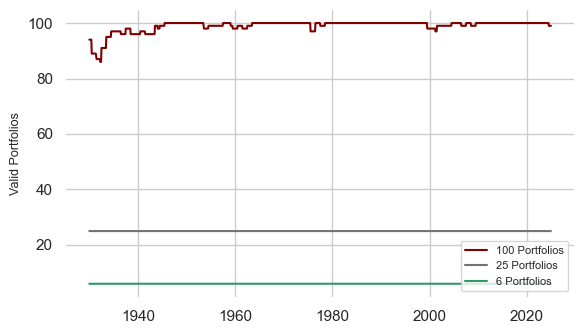

In [22]:
display(Image(filename=OUTPUT_DIR / "data_sparsity.png"))

## 4. The Three-Pass Regression Filter

The core methodology extracts a single predictive factor $F_t$ from the cross-section of BM ratios. We demonstrate each stage using the **25 Portfolios** with a **1-month forecast horizon** ($h=1$).

### Stage 1: Time-Series Regressions (Estimating Sensitivities)

For each portfolio $i$, we estimate its sensitivity to future market returns via a time-series regression:

$$v_{i,t} = \phi_{i,0} + \phi_i \, y_{t+h} + e_{i,t}$$

The slope coefficient $\phi_i$ measures how much portfolio $i$'s BM ratio moves with future market returns. Portfolios with larger $|\phi_i|$ carry more predictive information.

In [23]:
# Run Stage 1 on the full sample
y_full = mkt['Log_Mkt']
common_idx = bm_25.index.intersection(y_full.index)
v_aligned = bm_25.loc[common_idx]
y_aligned = y_full.loc[common_idx]

phi = rt.first_stage_regressions(v_aligned, y_aligned, h=1)
print(f"Estimated sensitivities for {len(phi)} portfolios:")
print(f"  Range: [{phi.min():.4f}, {phi.max():.4f}]")
print(f"  Mean:  {phi.mean():.4f}")
print(f"  Std:   {phi.std():.4f}")
print(f"\nTop 5 most sensitive portfolios:")
display(phi.sort_values(ascending=False).head().to_frame('phi'))

Estimated sensitivities for 25 portfolios:
  Range: [-0.0165, 0.4605]
  Mean:  0.2507
  Std:   0.1110

Top 5 most sensitive portfolios:


,phi
SMALL LoBM,0.460517
BIG LoBM,0.412685
ME4 BM1,0.401771
ME3 BM1,0.373954
ME5 BM2,0.313102


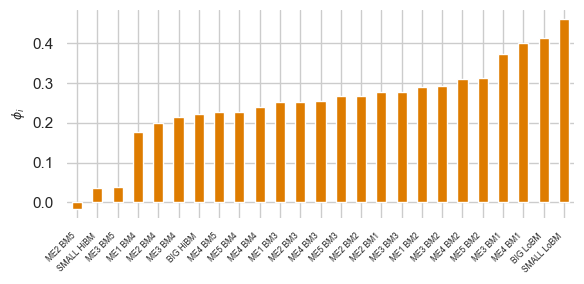

In [24]:
display(Image(filename=OUTPUT_DIR / "stage_1_sensitivities.png"))

### Stage 2: Cross-Sectional Regressions (Extracting the Factor)

At each time $t$, we regress the cross-section of BM ratios onto the estimated sensitivities:

$$v_{i,t} = c_t + F_t \, \phi_i + w_{i,t}$$

The slope $F_t$ is our extracted latent factor — a single time series that aggregates the predictive content of all portfolios.

In [25]:
F_series = rt.second_stage_regressions(v_aligned, phi)
print(f"Extracted factor F_t: {len(F_series)} observations")
print(f"  Date range: {F_series.index.min().strftime('%Y-%m')} to {F_series.index.max().strftime('%Y-%m')}")
print(f"  Mean:  {F_series.mean():.4f}")
print(f"  Std:   {F_series.std():.4f}")
print(f"  Correlation with log market return: {F_series.corr(y_aligned.reindex(F_series.index)):.4f}")

Extracted factor F_t: 1140 observations
  Date range: 1930-01 to 2024-12
  Mean:  -5.6381
  Std:   1.1884
  Correlation with log market return: 0.0352


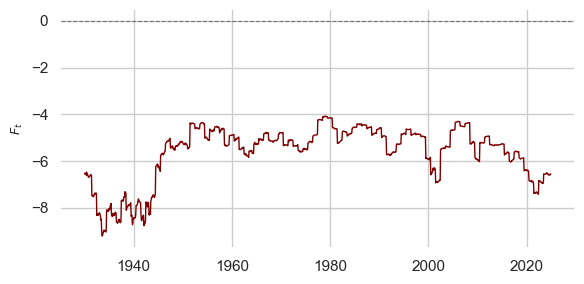

In [26]:
display(Image(filename=OUTPUT_DIR / "stage_2_factor.png"))

### Stage 3: Predictive Regression

Finally, we regress future market returns on the lagged factor:

$$y_{t+h} = \beta_0 + \beta \, F_t + u_{t+h}$$

If $F_t$ captures genuine predictive information, $\beta$ should be statistically significant and the $R^2$ should be meaningfully positive.

In [27]:
model = rt.third_stage_regression(F_series, y_aligned, h=1)
print("Stage 3 Predictive Regression Results:")
print(f"  Intercept (beta_0): {model.params.iloc[0]:.6f}")
print(f"  Slope (beta):       {model.params.iloc[1]:.6f}")
print(f"  In-sample R²:       {model.rsquared:.4f} ({model.rsquared * 100:.2f}%)")
print(f"  t-stat (slope):     {model.tvalues.iloc[1]:.4f}")
print(f"  p-value (slope):    {model.pvalues.iloc[1]:.4f}")
print(f"  N observations:     {int(model.nobs)}")

Stage 3 Predictive Regression Results:
  Intercept (beta_0): 0.019072
  Slope (beta):       0.001980
  In-sample R²:       0.0020 (0.20%)
  t-stat (slope):     1.5019
  p-value (slope):    0.1334
  N observations:     1139


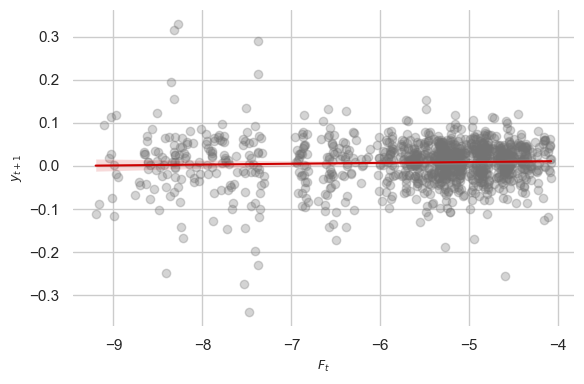

In [28]:
display(Image(filename=OUTPUT_DIR / "stage_3_predictive.png"))

## 5. Table 1 Replication Results

Table 1 reports in-sample (IS) and out-of-sample (OOS) predictive $R^2$ values across three portfolio granularities (6, 25, 100) and two forecast horizons (1-month, 1-year). The out-of-sample evaluation uses an **expanding window** — at each test date, the model is re-estimated using only data available up to that point.

We compare our replication against the published values:

In [29]:
# Load pre-computed Table 1 results (from replication.py pipeline)
try:
    df_original = pd.read_csv(OUTPUT_DIR / "table_1_results_original.csv", index_col=0)
    
    # Published values from the paper
    paper_values = pd.DataFrame({
        "1-Year IS": {"6 Portfolios": 7.72, "25 Portfolios": 13.50, "100 Portfolios": 18.05},
        "1-Year OOS": {"6 Portfolios": 5.81, "25 Portfolios": 3.49, "100 Portfolios": 13.07},
        "1-Month IS": {"6 Portfolios": 0.60, "25 Portfolios": 1.12, "100 Portfolios": 2.38},
        "1-Month OOS": {"6 Portfolios": 0.65, "25 Portfolios": 0.77, "100 Portfolios": 0.93},
    })
    paper_values.index.name = "Portfolio Set"
    
    print("=" * 70)
    print("PUBLISHED VALUES (Kelly & Pruitt 2013, Table 1)")
    print("=" * 70)
    display(paper_values.style.format('{:.2f}'))
    
    print("\n" + "=" * 70)
    print("OUR REPLICATION (Train: 1930-1980, Test: 1980-2010)")
    print("=" * 70)
    display(df_original.style.format('{:.2f}'))
    
    # Compute differences
    diff = df_original - paper_values
    print("\n" + "=" * 70)
    print("DIFFERENCE (Replication - Published)")
    print("=" * 70)
    display(diff.style.format('{:+.2f}'))
    
except FileNotFoundError:
    print("Table 1 results not yet computed. Run 'doit run_replication' first.")
    print("(The out-of-sample expanding window computation takes ~20 minutes.)")

PUBLISHED VALUES (Kelly & Pruitt 2013, Table 1)


,1-Year IS,1-Year OOS,1-Month IS,1-Month OOS
Portfolio Set,,,,
6 Portfolios,7.72,5.81,0.60,0.65
25 Portfolios,13.50,3.49,1.12,0.77
100 Portfolios,18.05,13.07,2.38,0.93



OUR REPLICATION (Train: 1930-1980, Test: 1980-2010)


,1-Year IS,1-Year OOS,1-Month IS,1-Month OOS
Portfolio Set,,,,
6 Portfolios,5.44,5.32,0.74,0.91
25 Portfolios,5.59,5.55,0.83,1.10
100 Portfolios,6.31,5.49,1.58,1.41



DIFFERENCE (Replication - Published)


,1-Year IS,1-Year OOS,1-Month IS,1-Month OOS
Portfolio Set,,,,
6 Portfolios,-2.28,-0.49,+0.14,+0.26
25 Portfolios,-7.91,+2.06,-0.29,+0.33
100 Portfolios,-11.74,-7.58,-0.80,+0.48
